In [ ]:
# Generate a complete PCA example for swimmers.
# This code will produce:
# - a synthetic data table (80 swimmers, 6 variables)
# - standardization, PCA (2 components)
# - loadings table (variable <-> component correlations)
# - scatter plot of individuals on the PC1 x PC2 plane
# - correlation circle (variables projected on component space)

# Uses matplotlib (not seaborn)

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from IPython.display import display

In [ ]:
# create of a dataset synthetic for 80 swimmers
n = 80
data = pd.DataFrame({
    "time_50": np.random.normal(loc=28, scale=1.2, size=n),  # 50m time in seconds 
    "time_100": np.random.normal(loc=62, scale=2.5, size=n), # 100m time in seconds
    "hr": np.random.normal(loc=150, scale=8, size=n),        # average heart rate
    "speed": np.random.normal(loc=1.8, scale=0.15, size=n),  # speed m/s
    "fatigue": np.random.normal(loc=3.5, scale=1.0, size=n), # subjective index (1-7)
    "strokes": np.random.normal(loc=20, scale=2.0, size=n)   # arms strokes per 25m 
})

data.head()


,time_50,time_100,hr,speed,fatigue,strokes
0,27.129508,63.206966,148.013101,1.942198,4.378585,18.887134
1,28.378058,64.929061,156.931141,1.654992,2.157358,19.742082
2,27.212915,60.472422,146.813679,1.638684,4.464973,17.654442
3,27.582959,63.627799,154.987495,1.517870,3.974013,19.462040
4,25.432249,59.382177,138.269079,1.756090,3.758596,19.973230


In [3]:
# Add some artificial correlations to make the example more realistic
# Improve correlations between times and speed / HR
data["speed"] = data["speed"] + (28 - data["time_50"]) * 0.02
data["hr"] = data["hr"] + (data["speed"] - 1.8) * 10
data["fatigue"] = data["fatigue"] + (data["time_100"] - 62) * 0.05
data["strokes"] = data["strokes"] + (28 - data["time_50"]) * 0.3


### Synthetic data - swimmers

In [4]:
display(data.round(3))


,time_50,time_100,hr,speed,fatigue,strokes
0,27.130,63.207,149.609,1.960,4.439,19.148
1,28.378,64.929,155.405,1.647,2.304,19.629
2,27.213,60.472,145.358,1.654,4.389,17.891
3,27.583,63.628,152.250,1.526,4.055,19.587
4,25.432,59.382,138.344,1.807,3.628,20.744
...,...,...,...,...,...,...
75,27.689,58.080,148.588,1.767,1.550,20.760
76,29.388,65.711,149.327,1.751,3.311,18.855
77,27.994,59.925,155.485,1.730,2.072,17.933
78,29.448,63.516,156.299,1.808,0.414,17.716


In [5]:
# Standardization
scaler = StandardScaler()
X_std = scaler.fit_transform(data)

In [6]:
# PCA
pca = PCA(n_components=2)
scores = pca.fit_transform(X_std)  # projections des individus
explained = pca.explained_variance_ratio_

In [7]:
# Compute correlations between variables and components (correlation circle)
# We compute the correlation between each standardized variable and each component (scores)
corr_var_comp = np.corrcoef(X_std.T, scores.T)[:X_std.shape[1], X_std.shape[1]:]
corr_df = pd.DataFrame(corr_var_comp, index=data.columns, columns=["PC1", "PC2"])

In [8]:
# Component (loadings) table as returned by sklearn (components as eigenvectors)
loadings = pd.DataFrame(pca.components_.T, index=data.columns, columns=["PC1_raw", "PC2_raw"])

In [9]:
# Display results
display("Raw loadings (eigenvectors)", loadings.round(4))
display("Variable <-> component correlations (correlation circle)", corr_df.round(4))

'Raw loadings (eigenvectors)'

,PC1_raw,PC2_raw
time_50,0.5399,-0.3144
time_100,0.0182,0.0969
hr,0.5962,0.4706
speed,0.0728,0.7076
fatigue,-0.1942,-0.1949
strokes,-0.5565,0.3628


'Variable <-> component correlations (correlation circle)'

,PC1,PC2
time_50,0.6167,-0.3433
time_100,0.0208,0.1058
hr,0.6810,0.5138
speed,0.0831,0.7726
fatigue,-0.2218,-0.2128
strokes,-0.6356,0.3961


In [10]:
# Explained variance summary
explained_df = pd.DataFrame({
    "PC": ["PC1", "PC2"],
    "Explained variance ratio": explained
})
display("Explained variance per component", explained_df.round(4))

'Explained variance per component'

,PC,Explained variance ratio
0,PC1,0.2174
1,PC2,0.1987


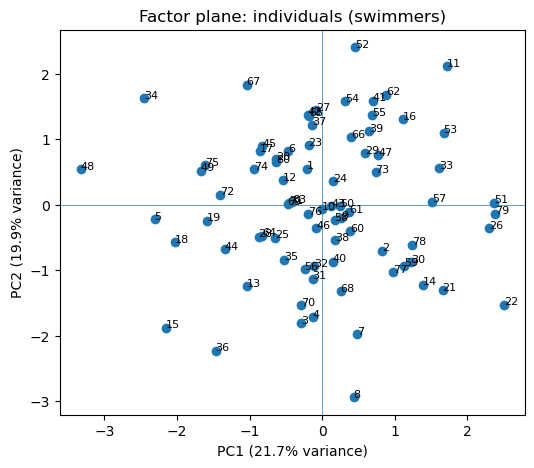

In [11]:
# Plot 1: individuals on the PC1 x PC2 plane
fig1, ax1 = plt.subplots(figsize=(6,5))
ax1.scatter(scores[:,0], scores[:,1])
for i, txt in enumerate(range(1, n+1)):
    ax1.annotate(str(txt), (scores[i,0], scores[i,1]), fontsize=8)
ax1.set_xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
ax1.set_ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
ax1.set_title("Factor plane: individuals (swimmers)")
ax1.axhline(0, linewidth=0.5)
ax1.axvline(0, linewidth=0.5)
plt.show()

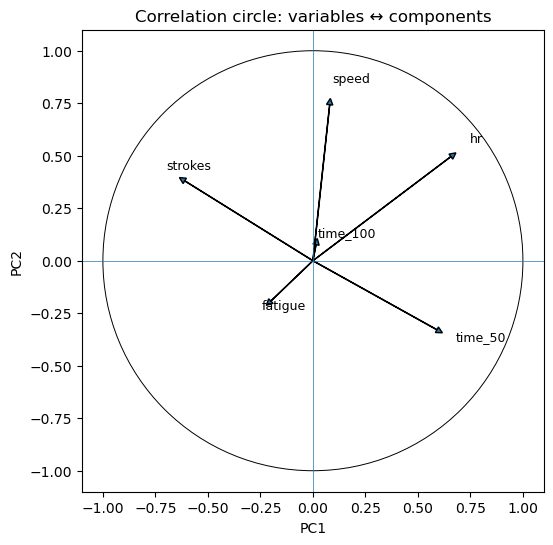

In [ ]:
# Plot 2: correlation circle
fig2, ax2 = plt.subplots(figsize=(6,6))
# unit circle
circle = plt.Circle((0,0), 1, color='black', fill=False, linewidth=0.7)
ax2.add_artist(circle)
# arrows for each variable
for i, var in enumerate(data.columns):
    x = corr_var_comp[i,0]
    y = corr_var_comp[i,1]
    ax2.arrow(0, 0, x, y, head_width=0.03, head_length=0.03, length_includes_head=True)
    ax2.text(x*1.1, y*1.1, var, fontsize=9)
ax2.set_xlim(-1.1, 1.1)
ax2.set_ylim(-1.1, 1.1)
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_title("Correlation circle: variables ↔ components")
ax2.axhline(0, linewidth=0.5)
ax2.axvline(0, linewidth=0.5)
ax2.set_aspect('equal', 'box')
plt.show()

In [ ]:
# Display individual scores (projections)
scores_df = pd.DataFrame(scores, columns=["PC1_score", "PC2_score"])
scores_df.index = [f"Swimmer_{i}" for i in range(1, n+1)]
display("Individuals' scores (projections on PC1/PC2)", scores_df.round(4))

"Individuals' scores (projections on PC1/PC2)"

,PC1_score,PC2_score
Swimmer_1,-0.2123,0.5533
Swimmer_2,0.8301,-0.7017
Swimmer_3,-0.2951,-1.8137
Swimmer_4,-0.1304,-1.7214
Swimmer_5,-2.3083,-0.2190
...,...,...
Swimmer_76,-0.1985,-0.1413
Swimmer_77,0.9716,-1.0337
Swimmer_78,1.2376,-0.6113
Swimmer_79,2.3777,-0.1347
